In [ ]:
# =========================
!pip install -q albumentations umap-learn seaborn scikit-learn



In [ ]:
# Colab setup
!pip install -q timm albumentations umap-learn seaborn

import os, torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

from google.colab import drive
drive.mount("/content/drive")

# Find your ZIP in Google Drive
!find /content/drive/MyDrive -iname "*.zip"

CUDA available: True
Device: Tesla T4
Mounted at /content/drive
/content/drive/MyDrive/archive.zip


In [ ]:
import os

# Paths
zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/brisc2025"

# Clean + extract
!rm -rf "$extract_path"
!mkdir -p "$extract_path"

print("ZIP file:")
!ls -lh "$zip_path"

!unzip -q "$zip_path" -d "$extract_path"

# ✅ CORRECT dataset path (FIXED)
DATASET_PATH = "/content/brisc2025/brisc2025/classification_task"

# Verify dataset
print("\n--- VERIFICATION ---")
print("DATASET_PATH:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))

if os.path.exists(DATASET_PATH):
    print("\nContents:", os.listdir(DATASET_PATH))

    train_path = os.path.join(DATASET_PATH, "train")
    test_path = os.path.join(DATASET_PATH, "test")

    print("\nTrain exists:", os.path.exists(train_path))
    print("Test exists:", os.path.exists(test_path))

    if os.path.exists(train_path):
        print("Train classes:", os.listdir(train_path))

    if os.path.exists(test_path):
        print("Test classes:", os.listdir(test_path))
else:
    print("\n❌ Dataset path incorrect. Full structure:")
    !find "$extract_path" -maxdepth 5 -type d

ZIP file:
-rw------- 1 root root 251M May  1 17:55 /content/drive/MyDrive/archive.zip

--- VERIFICATION ---
DATASET_PATH: /content/brisc2025/brisc2025/classification_task
Exists: True

Contents: ['test', 'train']

Train exists: True
Test exists: True
Train classes: ['no_tumor', 'glioma', 'pituitary', 'meningioma']
Test classes: ['no_tumor', 'glioma', 'pituitary', 'meningioma']


In [ ]:
# =========================
import os, glob, random, hashlib, copy, math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, classification_report
)
import umap

import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True


# Change only these if needed
DATA_ROOT = "/content/brisc2025/brisc2025"
CLASSIFICATION_PATH = os.path.join(DATA_ROOT, "classification_task")
SEGMENTATION_PATH = os.path.join(DATA_ROOT, "segmentation_task")

IMG_SIZE = 224
BATCH_SIZE_CLS = 32
BATCH_SIZE_SEG = 16
EPOCHS = 35
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 7
NUM_WORKERS = 2

print("Classification path exists:", os.path.exists(CLASSIFICATION_PATH))
print("Segmentation path exists:", os.path.exists(SEGMENTATION_PATH))



Classification path exists: True
Segmentation path exists: True


In [ ]:
# =========================
IMG_EXTS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")

def list_images(folder):
    files = []
    for ext in IMG_EXTS:
        files.extend(glob.glob(os.path.join(folder, "**", ext), recursive=True))
    return sorted(files)

def sha256_file(path, block_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            h.update(block)
    return h.hexdigest()

def remove_exact_duplicates(paths):
    """Returns unique paths; does not delete files from disk."""
    seen = {}
    unique, duplicates = [], []
    for p in tqdm(paths, desc="Hashing images"):
        try:
            h = sha256_file(p)
            if h in seen:
                duplicates.append((p, seen[h]))
            else:
                seen[h] = p
                unique.append(p)
        except Exception as e:
            print("Skipping unreadable file:", p, e)
    print(f"Total: {len(paths)} | Unique: {len(unique)} | Duplicates removed: {len(duplicates)}")
    return unique, duplicates



In [ ]:
# =========================
def build_classification_dataframe(root):
    rows = []
    class_names = sorted([d for d in os.listdir(os.path.join(root, "train")) if os.path.isdir(os.path.join(root, "train", d))])
    class_to_idx = {c:i for i,c in enumerate(class_names)}

    for split in ["train", "test"]:
        for cls in class_names:
            folder = os.path.join(root, split, cls)
            for p in list_images(folder):
                rows.append({"path": p, "label": class_to_idx[cls], "class_name": cls, "original_split": split})
    return pd.DataFrame(rows), class_names, class_to_idx

cls_df, class_names, class_to_idx = build_classification_dataframe(CLASSIFICATION_PATH)
print("Classes:", class_to_idx)
print(cls_df.groupby(["original_split", "class_name"]).size())

# Remove duplicates separately from classification data
unique_cls_paths, cls_dups = remove_exact_duplicates(cls_df["path"].tolist())
cls_df = cls_df[cls_df["path"].isin(set(unique_cls_paths))].reset_index(drop=True)

# Safe split: keep official test untouched; split official train into train/val stratified
cls_train_df = cls_df[cls_df.original_split == "train"].reset_index(drop=True)
cls_test_df  = cls_df[cls_df.original_split == "test"].reset_index(drop=True)

cls_train_df, cls_val_df = train_test_split(
    cls_train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=cls_train_df["label"]
)
cls_train_df = cls_train_df.reset_index(drop=True)
cls_val_df = cls_val_df.reset_index(drop=True)

print("Classification split sizes:", len(cls_train_df), len(cls_val_df), len(cls_test_df))

# Segmentation dataframe
def find_mask_for_image(img_path, images_root, masks_root):
    rel = os.path.relpath(img_path, images_root)
    stem = os.path.splitext(rel)[0]
    for ext in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]:
        candidate = os.path.join(masks_root, stem + ext)
        if os.path.exists(candidate):
            return candidate
    # fallback by basename search
    base = os.path.splitext(os.path.basename(img_path))[0]
    matches = glob.glob(os.path.join(masks_root, "**", base + ".*"), recursive=True)
    return matches[0] if matches else None

def build_segmentation_dataframe(root):
    rows = []
    for split in ["train", "test"]:
        images_root = os.path.join(root, split, "images")
        masks_root = os.path.join(root, split, "masks")
        for img_path in list_images(images_root):
            mask_path = find_mask_for_image(img_path, images_root, masks_root)
            if mask_path is not None:
                rows.append({"image_path": img_path, "mask_path": mask_path, "original_split": split})
    return pd.DataFrame(rows)

seg_df = build_segmentation_dataframe(SEGMENTATION_PATH)
print("Segmentation total:", len(seg_df))
print(seg_df.groupby("original_split").size())

unique_seg_paths, seg_dups = remove_exact_duplicates(seg_df["image_path"].tolist())
seg_df = seg_df[seg_df["image_path"].isin(set(unique_seg_paths))].reset_index(drop=True)

seg_train_df = seg_df[seg_df.original_split == "train"].reset_index(drop=True)
seg_test_df  = seg_df[seg_df.original_split == "test"].reset_index(drop=True)
seg_train_df, seg_val_df = train_test_split(seg_train_df, test_size=0.15, random_state=SEED)
seg_train_df = seg_train_df.reset_index(drop=True)
seg_val_df = seg_val_df.reset_index(drop=True)

print("Segmentation split sizes:", len(seg_train_df), len(seg_val_df), len(seg_test_df))



Classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
original_split  class_name
test            glioma         254
                meningioma     306
                no_tumor       140
                pituitary      300
train           glioma        1147
                meningioma    1329
                no_tumor      1067
                pituitary     1457
dtype: int64


Hashing images:   0%|          | 0/6000 [00:00<?, ?it/s]

Total: 6000 | Unique: 5950 | Duplicates removed: 50
Classification split sizes: 4217 745 988
Segmentation total: 4793
original_split
test      860
train    3933
dtype: int64


Hashing images:   0%|          | 0/4793 [00:00<?, ?it/s]

Total: 4793 | Unique: 4753 | Duplicates removed: 40
Segmentation split sizes: 3318 586 849


In [ ]:
# =========================
# 5. Augmentations + datasets


In [ ]:
# =========================
cls_train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.04, scale_limit=0.08, rotate_limit=12, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.RandomBrightnessContrast(p=0.35),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.CoarseDropout(max_holes=6, max_height=24, max_width=24, p=0.25),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

cls_eval_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

seg_train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.04, scale_limit=0.08, rotate_limit=12, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.RandomBrightnessContrast(p=0.35),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

seg_eval_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

class ClassificationDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)["image"]
        label = torch.tensor(row.label, dtype=torch.long)
        return img, label

class SegmentationDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            out = self.transform(image=img, mask=mask)
            img, mask = out["image"], out["mask"]
        mask = mask.unsqueeze(0).float() if mask.ndim == 2 else mask.float()
        return img, mask

cls_train_loader = DataLoader(ClassificationDataset(cls_train_df, cls_train_tfms), batch_size=BATCH_SIZE_CLS, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
cls_val_loader   = DataLoader(ClassificationDataset(cls_val_df, cls_eval_tfms), batch_size=BATCH_SIZE_CLS, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
cls_test_loader  = DataLoader(ClassificationDataset(cls_test_df, cls_eval_tfms), batch_size=BATCH_SIZE_CLS, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

seg_train_loader = DataLoader(SegmentationDataset(seg_train_df, seg_train_tfms), batch_size=BATCH_SIZE_SEG, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
seg_val_loader   = DataLoader(SegmentationDataset(seg_val_df, seg_eval_tfms), batch_size=BATCH_SIZE_SEG, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
seg_test_loader  = DataLoader(SegmentationDataset(seg_test_df, seg_eval_tfms), batch_size=BATCH_SIZE_SEG, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)



/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1116/3738157594.py:8: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=24, max_width=24, p=0.25),


In [ ]:
# =========================
# 6. Custom CNN U-Net model


In [ ]:
import torch

# =========================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        )
    def forward(self, x):
        return self.block(x)

class CustomUNetMultiTask(nn.Module):
    def __init__(self, num_classes=4, base=32, dropout=0.25):
        super().__init__()
        # Shared encoder
        self.enc1 = ConvBlock(3, base, dropout=0.05)
        self.enc2 = ConvBlock(base, base*2, dropout=0.10)
        self.enc3 = ConvBlock(base*2, base*4, dropout=0.15)
        self.enc4 = ConvBlock(base*4, base*8, dropout=0.20)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(base*8, base*16, dropout=dropout)

        # Segmentation decoder with skip connections
        self.up4 = nn.ConvTranspose2d(base*16, base*8, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(base*16, base*8, dropout=0.15)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(base*8, base*4, dropout=0.10)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base*4, base*2, dropout=0.05)
        self.up1 = nn.ConvTranspose2d(base*2, base, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base*2, base, dropout=0.05)
        self.seg_head = nn.Conv2d(base, 1, kernel_size=1)

        # Classification head from bottleneck
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base*16, base*8),
            nn.BatchNorm1d(base*8),
            nn.ReLU(inplace=True),
            nn.Dropout(0.45),
            nn.Linear(base*8, num_classes)
        )

    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        return e1, e2, e3, e4, b

    def forward(self, x):
        e1, e2, e3, e4, b = self.encode(x)
        cls_logits = self.cls_head(b)

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        seg_logits = self.seg_head(d1)
        return cls_logits, seg_logits, b

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CustomUNetMultiTask(num_classes=len(class_names), base=32, dropout=0.25).to(DEVICE)
print("Parameters:", sum(p.numel() for p in model.parameters())/1e6, "M")


Parameters: 7.895909 M


In [ ]:
# =========================
# 7. Losses + metrics


In [ ]:
# =========================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        dims = (1,2,3)
        intersection = torch.sum(probs * targets, dims)
        union = torch.sum(probs, dims) + torch.sum(targets, dims)
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

def dice_iou_from_logits(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    dims = (1,2,3)
    inter = torch.sum(preds * targets, dims)
    pred_sum = torch.sum(preds, dims)
    target_sum = torch.sum(targets, dims)
    dice = (2*inter + smooth) / (pred_sum + target_sum + smooth)
    iou = (inter + smooth) / (pred_sum + target_sum - inter + smooth)
    return dice.mean().item(), iou.mean().item()

ce_loss = nn.CrossEntropyLoss(label_smoothing=0.08)
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())



/tmp/ipykernel_1116/454864333.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [ ]:
# =========================
# 8. Train/evaluate functions


In [ ]:
# =========================
def run_classification_eval(loader):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []
    features = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            cls_logits, _, bottleneck = model(images)
            loss = ce_loss(cls_logits, labels)
            total_loss += loss.item() * images.size(0)
            preds = cls_logits.argmax(1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            feat = F.adaptive_avg_pool2d(bottleneck, 1).flatten(1)
            features.append(feat.cpu().numpy())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    features = np.concatenate(features, axis=0) if features else np.empty((0, 1))
    return {
        "loss": total_loss / len(loader.dataset),
        "acc": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "y_true": y_true,
        "y_pred": y_pred,
        "features": features
    }

def run_segmentation_eval(loader):
    model.eval()
    total_loss = 0.0
    dices, ious = [], []
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            _, seg_logits, _ = model(images)
            loss = 0.5*bce_loss(seg_logits, masks) + 0.5*dice_loss(seg_logits, masks)
            total_loss += loss.item() * images.size(0)
            d, i = dice_iou_from_logits(seg_logits, masks)
            dices.append(d)
            ious.append(i)
    return {
        "loss": total_loss / len(loader.dataset),
        "dice": float(np.mean(dices)),
        "iou": float(np.mean(ious))
    }

def train_one_epoch():
    model.train()
    cls_iter = iter(cls_train_loader)
    seg_iter = iter(seg_train_loader)
    steps = max(len(cls_train_loader), len(seg_train_loader))

    total_loss = 0.0
    cls_true, cls_pred = [], []
    seg_dices, seg_ious = [], []

    for _ in tqdm(range(steps), desc="Training"):
        optimizer.zero_grad(set_to_none=True)
        loss_total = 0.0

        # Classification batch
        try:
            cls_images, labels = next(cls_iter)
        except StopIteration:
            cls_iter = iter(cls_train_loader)
            cls_images, labels = next(cls_iter)
        cls_images, labels = cls_images.to(DEVICE), labels.to(DEVICE)

        # Segmentation batch
        try:
            seg_images, masks = next(seg_iter)
        except StopIteration:
            seg_iter = iter(seg_train_loader)
            seg_images, masks = next(seg_iter)
        seg_images, masks = seg_images.to(DEVICE), masks.to(DEVICE)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            cls_logits, _, _ = model(cls_images)
            cls_loss = ce_loss(cls_logits, labels)

            _, seg_logits, _ = model(seg_images)
            seg_loss = 0.5*bce_loss(seg_logits, masks) + 0.5*dice_loss(seg_logits, masks)

            # Weighted multitask loss. Increase seg weight if segmentation underperforms.
            loss = cls_loss + seg_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = cls_logits.argmax(1)
        cls_true.extend(labels.detach().cpu().numpy())
        cls_pred.extend(preds.detach().cpu().numpy())
        d, i = dice_iou_from_logits(seg_logits.detach(), masks.detach())
        seg_dices.append(d)
        seg_ious.append(i)

    return {
        "loss": total_loss / steps,
        "acc": accuracy_score(cls_true, cls_pred),
        "dice": float(np.mean(seg_dices)),
        "iou": float(np.mean(seg_ious))
    }



In [ ]:
# =========================
# 9. Training loop with early stopping


In [ ]:
# =========================
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_dice": [], "val_dice": [],
    "train_iou": [], "val_iou": []
}

best_score = -1
best_state = None
bad_epochs = 0

for epoch in range(1, EPOCHS+1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    train_metrics = train_one_epoch()
    val_cls = run_classification_eval(cls_val_loader)
    val_seg = run_segmentation_eval(seg_val_loader)

    val_loss = val_cls["loss"] + val_seg["loss"]
    # Generalization-friendly model selection: classification F1 + Dice, not only accuracy
    score = 0.5 * val_cls["f1"] + 0.5 * val_seg["dice"]

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_metrics["acc"])
    history["val_acc"].append(val_cls["acc"])
    history["train_dice"].append(train_metrics["dice"])
    history["val_dice"].append(val_seg["dice"])
    history["train_iou"].append(train_metrics["iou"])
    history["val_iou"].append(val_seg["iou"])

    print(f"Train loss: {train_metrics['loss']:.4f} | Train acc: {train_metrics['acc']:.4f} | Train Dice: {train_metrics['dice']:.4f} | Train IoU: {train_metrics['iou']:.4f}")
    print(f"Val loss:   {val_loss:.4f} | Val acc:   {val_cls['acc']:.4f} | Val F1: {val_cls['f1']:.4f} | Val Bal Acc: {val_cls['balanced_acc']:.4f}")
    print(f"Val Precision: {val_cls['precision']:.4f} | Val Recall: {val_cls['recall']:.4f} | Val Dice: {val_seg['dice']:.4f} | Val IoU: {val_seg['iou']:.4f}")

    scheduler.step(score)

    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, "/content/best_custom_unet_multitask.pth")
        bad_epochs = 0
        print("Saved best model.")
    else:
        bad_epochs += 1
        print(f"No improvement: {bad_epochs}/{PATIENCE}")
        if bad_epochs >= PATIENCE:
            print("Early stopping triggered.")
            break

model.load_state_dict(torch.load("/content/best_custom_unet_multitask.pth", map_location=DEVICE))
print("Best score:", best_score)




Epoch 1/35


Training:   0%|          | 0/208 [00:00<?, ?it/s]

/tmp/ipykernel_1116/2866426038.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Train loss: 1.7385 | Train acc: 0.5888 | Train Dice: 0.1624 | Train IoU: 0.1116
Val loss:   1.3673 | Val acc:   0.7262 | Val F1: 0.7366 | Val Bal Acc: 0.7383
Val Precision: 0.7473 | Val Recall: 0.7383 | Val Dice: 0.3858 | Val IoU: 0.2922
Saved best model.

Epoch 2/35


Training:   0%|          | 0/208 [00:00<?, ?it/s]

...

/tmp/ipykernel_1116/2866426038.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Train loss: 0.4686 | Train acc: 0.9759 | Train Dice: 0.8335 | Train IoU: 0.7484
Val loss:   0.4611 | Val acc:   0.9758 | Val F1: 0.9762 | Val Bal Acc: 0.9756
Val Precision: 0.9772 | Val Recall: 0.9756 | Val Dice: 0.8078 | Val IoU: 0.7212
No improvement: 3/7

Epoch 35/35


Training:   0%|          | 0/208 [00:00<?, ?it/s]

/tmp/ipykernel_1116/2866426038.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Train loss: 0.4673 | Train acc: 0.9773 | Train Dice: 0.8360 | Train IoU: 0.7522
Val loss:   0.4427 | Val acc:   0.9839 | Val F1: 0.9837 | Val Bal Acc: 0.9835
Val Precision: 0.9839 | Val Recall: 0.9835 | Val Dice: 0.8236 | Val IoU: 0.7414
Saved best model.
Best score: 0.9036827275565745


In [ ]:
# =========================
# 10. Final test evaluation



========== FINAL CLASSIFICATION TEST ==========
Loss: 0.3496
Accuracy: 0.9798
Precision: 0.9771
Recall: 0.9827
F1: 0.9797
Balanced Accuracy: 0.9827

Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.98      0.98       253
  meningioma       0.98      0.96      0.97       301
    no_tumor       0.96      1.00      0.98       139
   pituitary       0.99      0.99      0.99       295

    accuracy                           0.98       988
   macro avg       0.98      0.98      0.98       988
weighted avg       0.98      0.98      0.98       988


========== FINAL SEGMENTATION TEST ==========
Loss: 0.0973
Dice: 0.8383
IoU: 0.7575


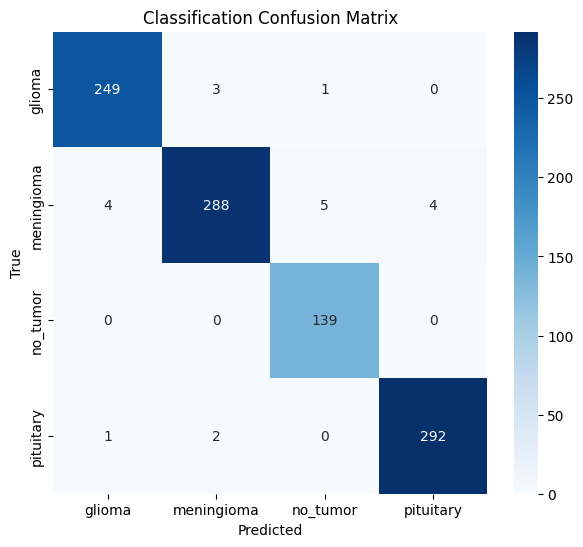

In [ ]:
# =========================
test_cls = run_classification_eval(cls_test_loader)
test_seg = run_segmentation_eval(seg_test_loader)

print("\n========== FINAL CLASSIFICATION TEST ==========")
print("Loss:", round(test_cls["loss"], 4))
print("Accuracy:", round(test_cls["acc"], 4))
print("Precision:", round(test_cls["precision"], 4))
print("Recall:", round(test_cls["recall"], 4))
print("F1:", round(test_cls["f1"], 4))
print("Balanced Accuracy:", round(test_cls["balanced_acc"], 4))
print("\nClassification Report:")
print(classification_report(test_cls["y_true"], test_cls["y_pred"], target_names=class_names, zero_division=0))

print("\n========== FINAL SEGMENTATION TEST ==========")
print("Loss:", round(test_seg["loss"], 4))
print("Dice:", round(test_seg["dice"], 4))
print("IoU:", round(test_seg["iou"], 4))

# Confusion matrix
cm = confusion_matrix(test_cls["y_true"], test_cls["y_pred"])
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Classification Confusion Matrix")
plt.show()



In [ ]:
# =========================
# 11. Curves


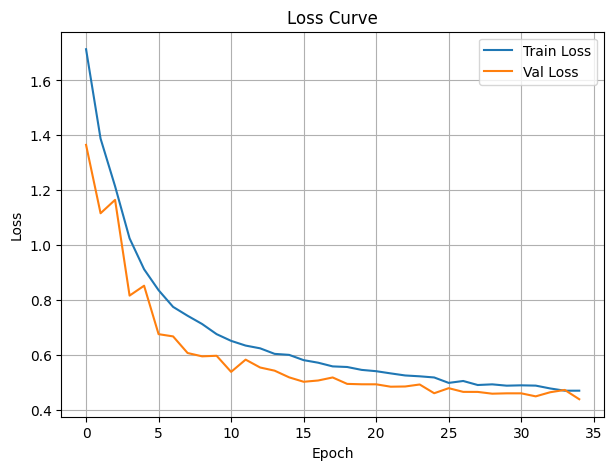

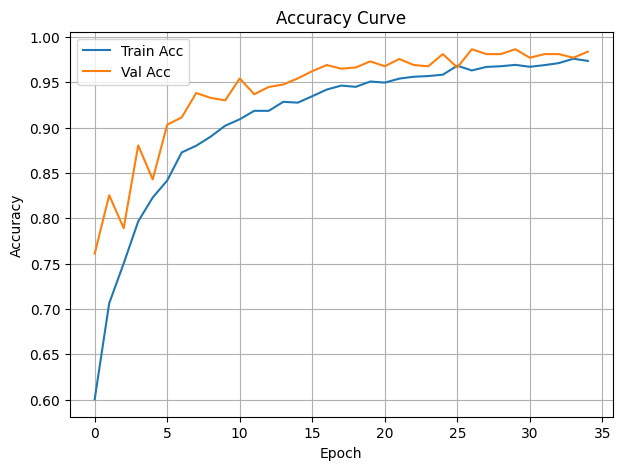

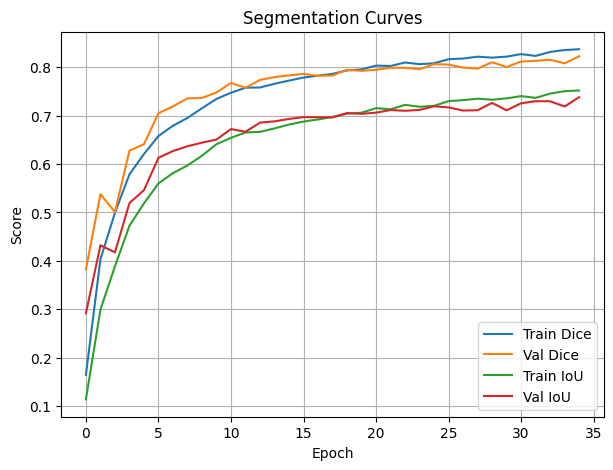

In [ ]:
# =========================
plt.figure(figsize=(7,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Val Dice")
plt.plot(history["train_iou"], label="Train IoU")
plt.plot(history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Segmentation Curves")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
# =========================
# 12. UMAP bottleneck visualization


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


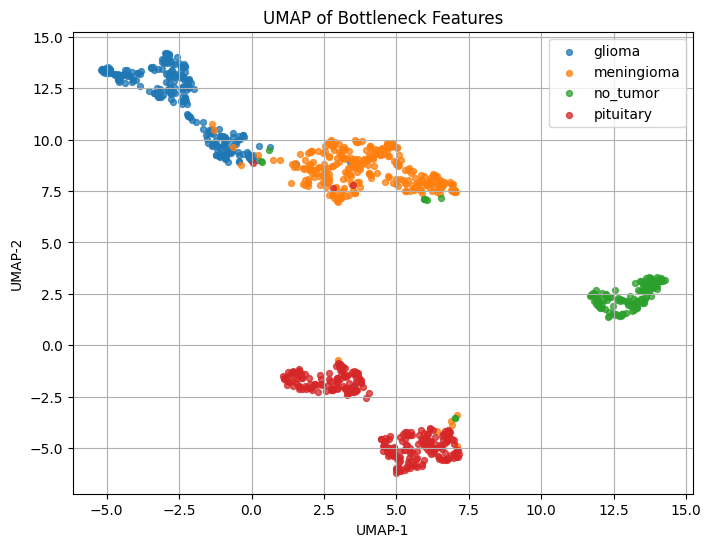

In [ ]:
# =========================
features = test_cls["features"]
labels = test_cls["y_true"]

if len(features) > 5:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.15, random_state=SEED)
    emb = reducer.fit_transform(features)
    plt.figure(figsize=(8,6))
    for i, cls in enumerate(class_names):
        idx = labels == i
        plt.scatter(emb[idx, 0], emb[idx, 1], s=18, label=cls, alpha=0.75)
    plt.title("UMAP of Bottleneck Features")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend()
    plt.grid(True)
    plt.show()



In [ ]:
# =========================
# 13. Visualize segmentation predictions


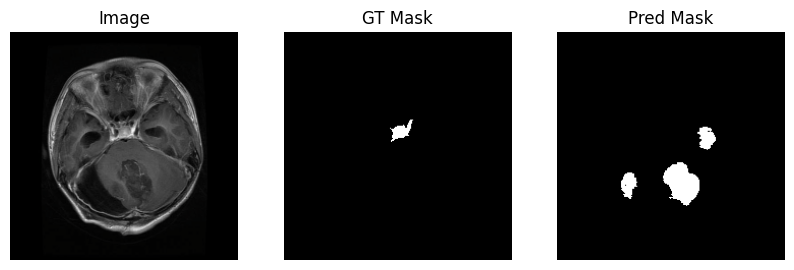

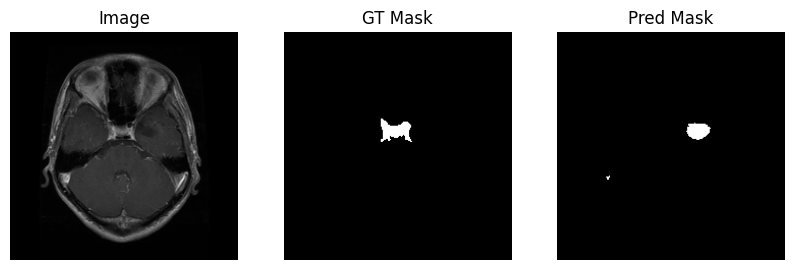

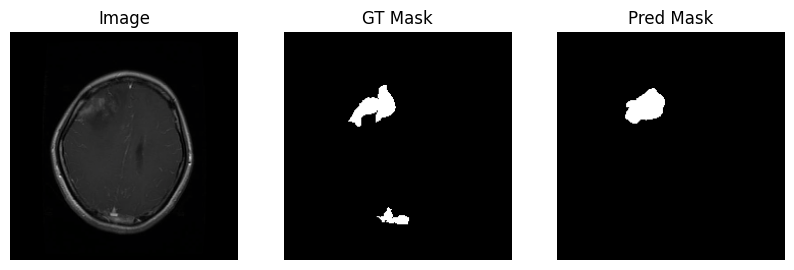

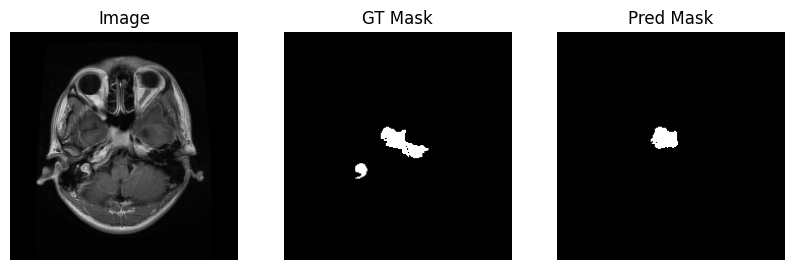

In [ ]:
# =========================
def show_seg_predictions(loader, n=4):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(DEVICE)
    with torch.no_grad():
        _, logits, _ = model(images)
        preds = (torch.sigmoid(logits) > 0.5).float().cpu()
    images = images.cpu()

    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

    n = min(n, images.size(0))
    for i in range(n):
        img = (images[i] * std + mean).clamp(0,1).permute(1,2,0).numpy()
        gt = masks[i,0].numpy()
        pr = preds[i,0].numpy()
        plt.figure(figsize=(10,3))
        plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
        plt.subplot(1,3,2); plt.imshow(gt, cmap="gray"); plt.title("GT Mask"); plt.axis("off")
        plt.subplot(1,3,3); plt.imshow(pr, cmap="gray"); plt.title("Pred Mask"); plt.axis("off")
        plt.show()

show_seg_predictions(seg_test_loader, n=4)
